# Analyse exploratoire des tweets suspects

Installation des dépendances

In [2]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn \
nltk imbalanced-learn transformers torch mlflow joblib wordcloud dvc[gdrive] cryptography==49.0.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.2/451.2 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41

Import des bibliothèques

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import joblib
import mlflow
import sklearn
import transformers
import torch

from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

Chargement du dataset

In [4]:
from google.colab import files

uploaded = files.upload()

Saving tweets_suspect.csv to tweets_suspect.csv


Lecture des données

In [5]:
df = pd.read_csv(next(iter(uploaded)))

df.head()

,message,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",1
1,is upset that he can't update his Facebook by ...,1
2,@Kenichan I dived many times for the ball. Man...,1
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",1


Informations générales

In [6]:
print(df.shape)

print(df.columns)

print(df.info())

print(df.isnull().sum())

(60000, 2)
Index(['message', 'label'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   message  60000 non-null  object
 1   label    60000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 937.6+ KB
None
message    0
label      0
dtype: int64


Distribution des classes

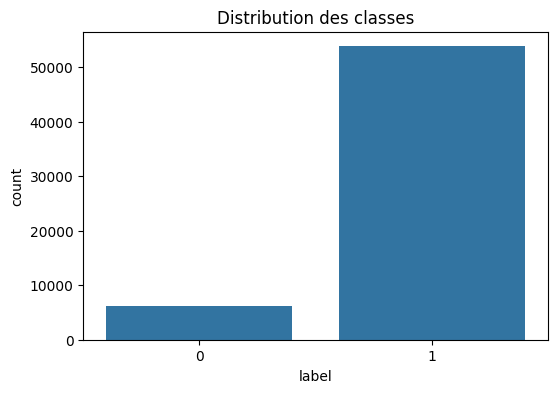

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='label',
    data=df
)

plt.title("Distribution des classes")

plt.show()

Longueur des tweets

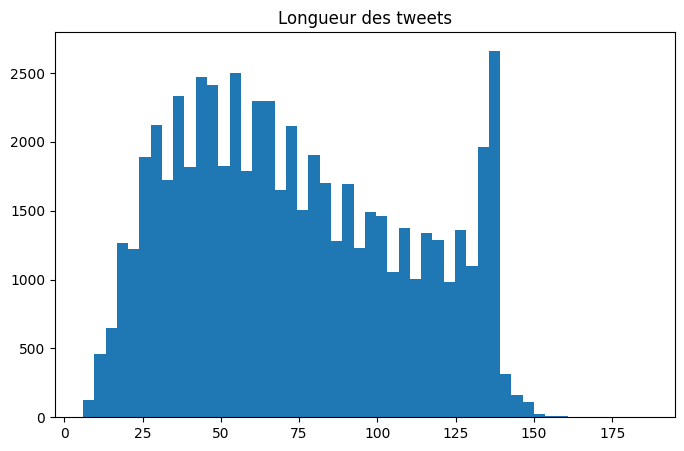

In [8]:
df["length"] = df["message"].apply(len)

plt.figure(figsize=(8,5))

plt.hist(df["length"], bins=50)

plt.title("Longueur des tweets")

plt.show()

Prétraitement des données

In [9]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["clean_message"] = df["message"].apply(clean_text)

Nuage de mots

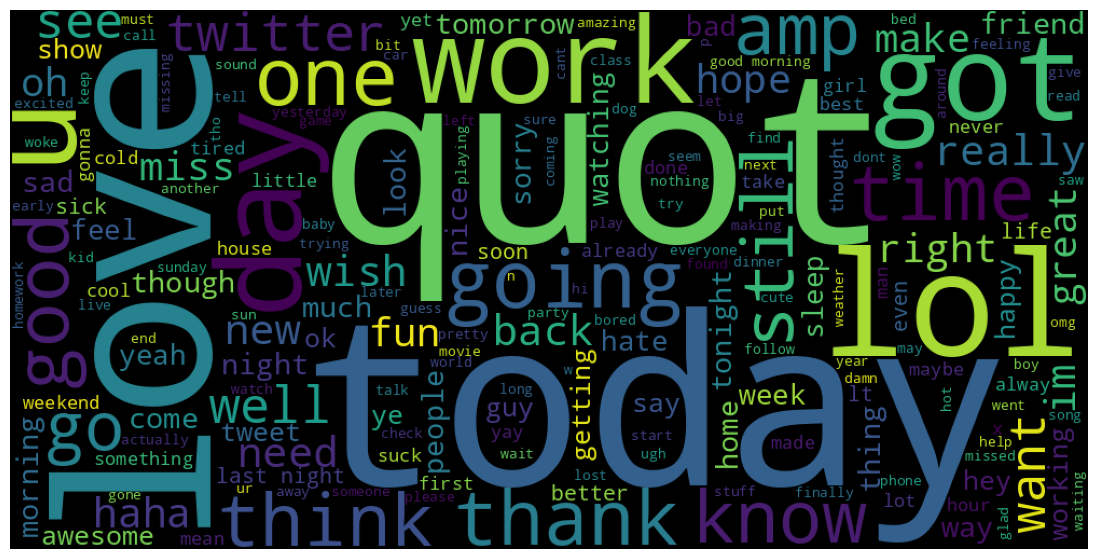

In [10]:
text = " ".join(df["clean_message"])

wordcloud = WordCloud(
    width=1000,
    height=500
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

TF-IDF

In [11]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(
    df["clean_message"]
)

y = df["label"]

Train Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

SMOTE

In [13]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

Logistic Regression

In [14]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr.fit(
    X_train_smote,
    y_train_smote
)

pred_lr = lr.predict(X_test)

Naive Bayes

In [15]:
nb = MultinomialNB()

nb.fit(
    X_train_smote,
    y_train_smote
)

pred_nb = nb.predict(X_test)

SVM

In [17]:
svm = LinearSVC(
    class_weight='balanced'
)

svm.fit(
    X_train_smote,
    y_train_smote
)

pred_svm = svm.predict(X_test)

Comparaison des modèles

In [18]:
models = {
    "Logistic Regression": pred_lr,
    "Naive Bayes": pred_nb,
    "SVM": pred_svm
}

for name, pred in models.items():

    print("="*50)

    print(name)

    print(
        classification_report(
            y_test,
            pred
        )
    )

Logistic Regression
              precision    recall  f1-score   support

           0       0.58      0.79      0.67      1229
           1       0.97      0.93      0.95     10771

    accuracy                           0.92     12000
   macro avg       0.78      0.86      0.81     12000
weighted avg       0.93      0.92      0.92     12000

Naive Bayes
              precision    recall  f1-score   support

           0       0.40      0.85      0.54      1229
           1       0.98      0.86      0.91     10771

    accuracy                           0.85     12000
   macro avg       0.69      0.85      0.73     12000
weighted avg       0.92      0.85      0.88     12000

SVM
              precision    recall  f1-score   support

           0       0.63      0.83      0.72      1229
           1       0.98      0.94      0.96     10771

    accuracy                           0.93     12000
   macro avg       0.80      0.89      0.84     12000
weighted avg       0.94      0.93     

Matrice de confusion

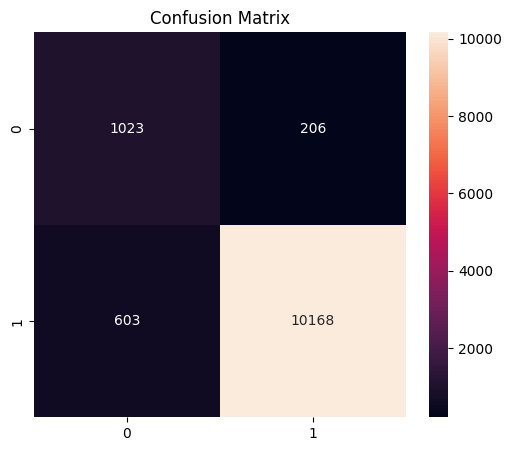

In [19]:
cm = confusion_matrix(
    y_test,
    pred_svm
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

Courbe ROC

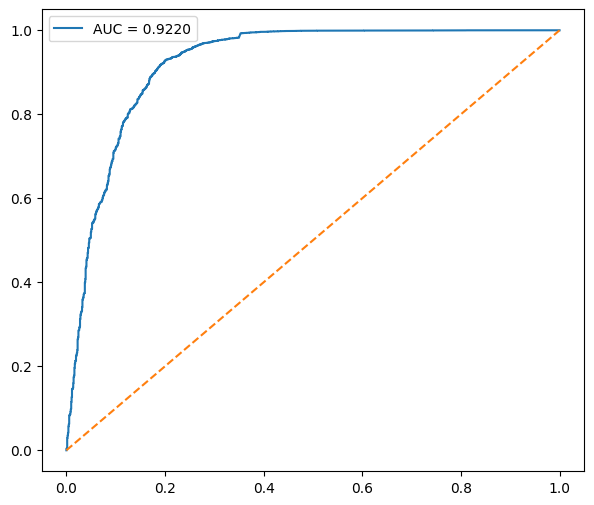

In [20]:
prob = lr.predict_proba(
    X_test
)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.legend()

plt.show()

Grid Search

In [21]:
params = {
    "C":[0.01,0.1,1,10]
}

grid = GridSearchCV(
    LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ),
    params,
    cv=5,
    scoring='f1'
)

grid.fit(
    X_train_smote,
    y_train_smote
)

print(grid.best_params_)

{'C': 10}


MLflow

In [22]:
mlflow.set_experiment(
    "tweets_suspects"
)

with mlflow.start_run():

    mlflow.log_param(
        "model",
        "LogisticRegression"
    )

    mlflow.log_metric(
        "auc",
        roc_auc
    )

2026/07/03 10:01:09 INFO mlflow.tracking.fluent: Experiment with name 'tweets_suspects' does not exist. Creating a new experiment.


Sauvegarde du modèle

In [23]:
joblib.dump(
    lr,
    "model.pkl"
)

joblib.dump(
    vectorizer,
    "vectorizer.pkl"
)

['vectorizer.pkl']

Test sur un nouveau tweet

In [24]:
tweet = """
I hate all people from this country
"""

tweet = clean_text(tweet)

tweet_vector = vectorizer.transform(
    [tweet]
)

prediction = lr.predict(
    tweet_vector
)

prob = lr.predict_proba(
    tweet_vector
)

print("Classe :", prediction[0])

print(
    "Probabilité :",
    prob.max()
)

Classe : 0
Probabilité : 0.9998810305309098


Téléchargement le modèle

In [25]:
from google.colab import files

files.download("model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>